# Waveshaping

Waveshaping generates **controlled harmonic content** by applying a polynomial transfer function sample-by-sample: `y = Σ cₖ xᵏ`. The polynomial coefficients directly determine which harmonics appear. Chebyshev polynomials of the first kind are particularly useful because `Tₙ(cos θ) = cos(nθ)` — applying Tₙ to a unit-amplitude sine at f generates a pure nth harmonic.

Bitcrushing reduces the amplitude resolution to `bits` bits by quantising to `2^(bits−1)` levels, introducing periodic quantisation noise with a characteristic lo-fi texture.

| Function | Description |
| --- | --- |
| `waveshape` | Polynomial waveshaper: `y = c0 + c1·x + c2·x² + …`. Coefficients determine harmonic content analytically. |
| `bitcrush` | Reduce signal to `bits`-bit amplitude resolution. Quantisation step = `2 / 2^bits`; output is a staircase approximation of the input. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.nonlinear import bitcrush, waveshape

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Polynomial waveshaping transfer curves / waveforms (top row) and bitcrushing at several bit depths (bottom row), all on a 440 Hz sine input.

**Top row — four polynomial shapes (2 × 4 grid, top half):**
- **Identity [0, 1]:** `y = x` — linear; no harmonic distortion; reference curve
- **T3 (Chebyshev 3rd) [−3, 0, 4]:** adds a 3rd harmonic; transfer curve is a single S-shape; mild warm saturation
- **Odd saturation [0, 1, 0, −0.3]:** cubic roll-off suppresses peaks; sounds like gentle tube compression
- **Chebyshev T5 [0, 5, 0, −20, 0, 16]:** adds a 5th harmonic; more complex transfer curve with a double inflection; bright, aggressive character

**Bottom row — bitcrush at four bit depths:**
- **8-bit:** subtle staircase; quantisation noise is 48 dB below signal (6 dB/bit rule)
- **4-bit:** clearly audible quantisation steps; noise floor rises to −24 dB
- **2-bit:** severe distortion; waveform approximated with only 4 levels; square-wave-like
- **1-bit:** pure comparator; output is ±1 only; classic lo-fi / ring-modulator texture


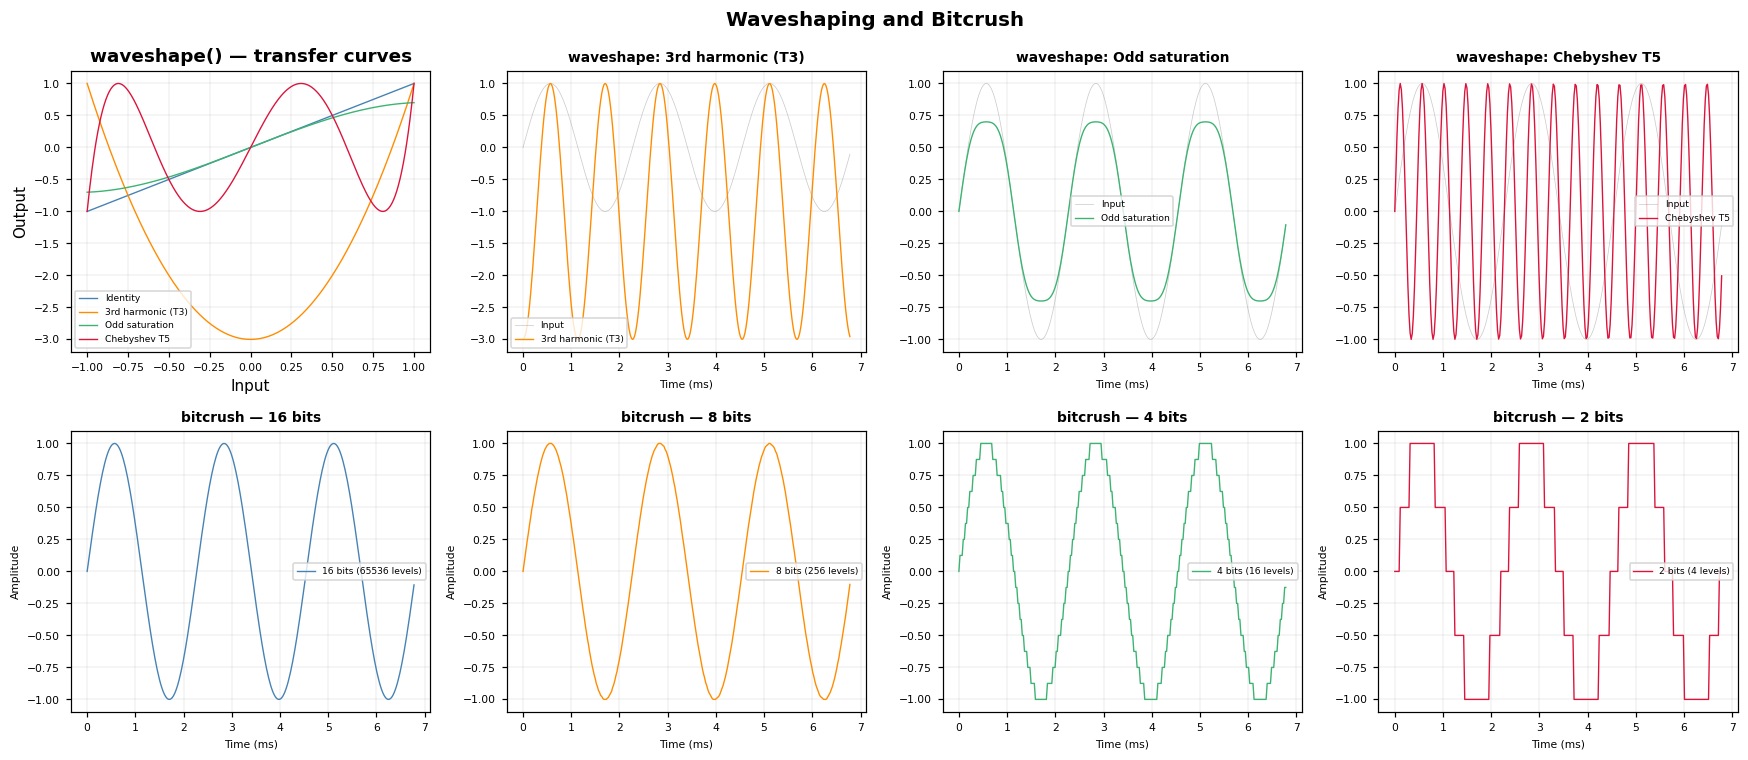

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 3 / FREQ

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000

COLORS = ["steelblue", "darkorange", "mediumseagreen", "crimson"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# waveshape: transfer curves and waveforms
x_tc = np.linspace(-1, 1, 400)
SHAPES = [
    ("Identity", [0, 1]),
    ("3rd harmonic (T3)", [-3, 0, 4]),
    ("Odd saturation", [0, 1, 0, -0.3]),
    ("Chebyshev T5", [0, 5, 0, -20, 0, 16]),
]

ax_tc = axes[0, 0]
ax_tc.set_title("waveshape() — transfer curves", fontweight="bold")
for (label, coeffs), color in zip(SHAPES, COLORS):
    ax_tc.plot(x_tc, np.polyval(list(reversed(coeffs)) if len(coeffs) > 1 else coeffs, x_tc), color=color, linewidth=0.9, label=label)
    # use np.polynomial.polynomial.polyval which uses ascending order
    ax_tc.clear()

# Redo with correct polyval
ax_tc = axes[0, 0]
ax_tc.set_title("waveshape() — transfer curves", fontweight="bold")
for (label, coeffs), color in zip(SHAPES, COLORS):
    y_tc = np.polynomial.polynomial.polyval(x_tc, coeffs)
    ax_tc.plot(x_tc, y_tc, color=color, linewidth=0.9, label=label)
ax_tc.legend(fontsize=6)
ax_tc.set_xlabel("Input")
ax_tc.set_ylabel("Output")

for col, ((label, coeffs), color) in enumerate(zip(SHAPES[1:], COLORS[1:]), start=1):
    out = waveshape(sig, coeffs)
    axes[0, col].plot(t_ms, sig, color="gray", linewidth=0.5, alpha=0.4, label="Input")
    axes[0, col].plot(t_ms, out, color=color, linewidth=0.9, label=label)
    axes[0, col].set_title(f"waveshape: {label}", fontsize=9, fontweight="bold")
    axes[0, col].legend(fontsize=6)
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)

# bitcrush
BITS = [16, 8, 4, 2]
for col, (bits, color) in enumerate(zip(BITS, COLORS)):
    out = bitcrush(sig, bits=bits)
    axes[1, col].plot(t_ms, out, color=color, linewidth=0.9, label=f"{bits} bits ({2**bits} levels)")
    axes[1, col].set_title(f"bitcrush — {bits} bits", fontsize=9, fontweight="bold")
    axes[1, col].legend(fontsize=6)
    axes[1, col].set_xlabel("Time (ms)", fontsize=7)
    axes[1, col].set_ylabel("Amplitude", fontsize=7)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("Waveshaping and Bitcrush", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Polynomial waveshaping adds controlled harmonics via Chebyshev polynomials. Bitcrushing reduces bit depth, introducing quantisation noise.


In [3]:
from IPython.display import Audio, display

DUR_A = 2.0
N_A   = int(FS * DUR_A)
t_a   = np.arange(N_A) / FS
sig_a = 0.8 * np.sin(2 * np.pi * 220.0 * t_a)

# T1 + 0.5*T3: adds 3rd harmonic
shaped_a  = waveshape(sig_a, coeffs=[0.0, 1.0, 0.0, 0.5])
crushed_a = bitcrush(sig_a, bits=4)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Clean sine at 220 Hz")
display(Audio(sig_a * 0.7, rate=FS))
print("Waveshaping (T1 + 0.5·T3 Chebyshev) — adds a controlled 3rd harmonic")
display(Audio(norm(shaped_a), rate=FS))
print("Bitcrush (4-bit) — quantisation noise, lo-fi digital grit")
display(Audio(norm(crushed_a), rate=FS))

Clean sine at 220 Hz


Waveshaping (T1 + 0.5·T3 Chebyshev) — adds a controlled 3rd harmonic


Bitcrush (4-bit) — quantisation noise, lo-fi digital grit
